In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("Mall_Customers.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.columns = [
    "CustomerID",
    "Gender",
    "Age",
    "Income",
    "SpendingScore"
]

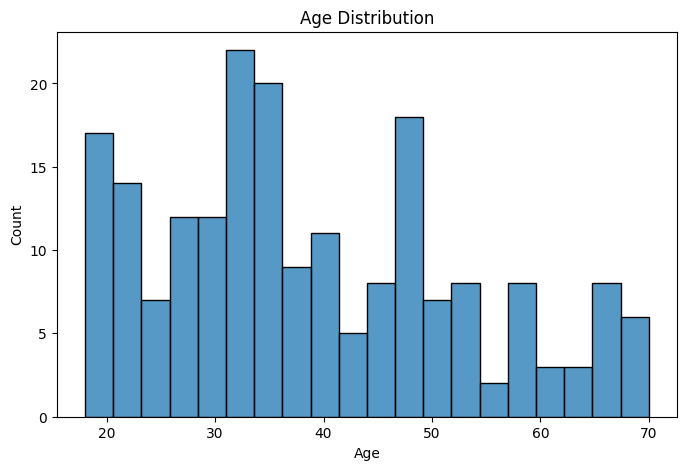

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20)

plt.title("Age Distribution")

plt.show()

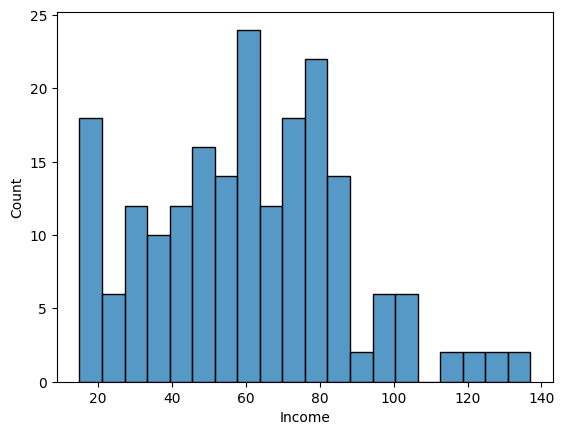

In [12]:
sns.histplot(df["Income"], bins=20)

plt.show()

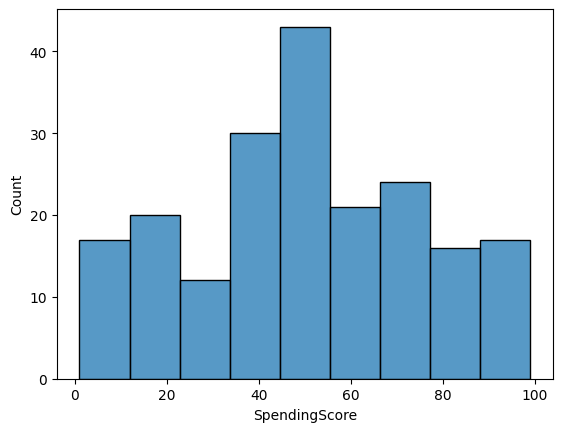

In [13]:
sns.histplot(df["SpendingScore"])

plt.show()

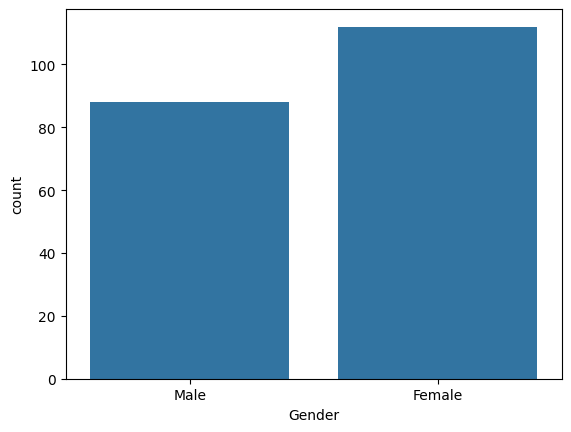

In [14]:
sns.countplot(x="Gender", data=df)

plt.show()

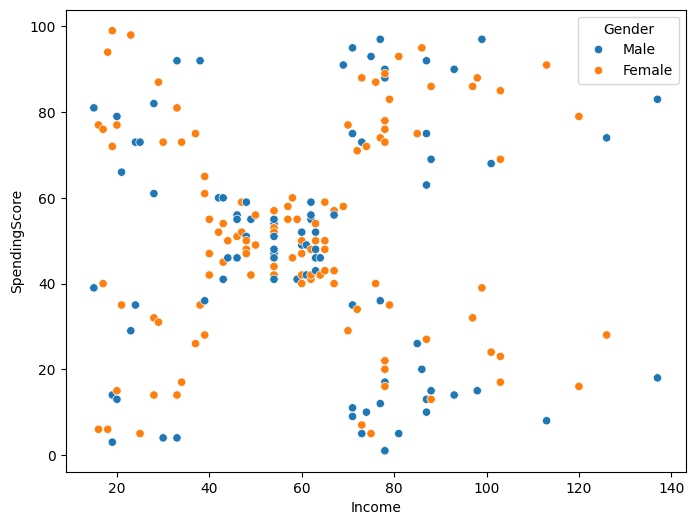

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Income",
    y="SpendingScore",
    hue="Gender",
    data=df
)

plt.show()

In [16]:
X = df[["Income", "SpendingScore"]]

In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [19]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

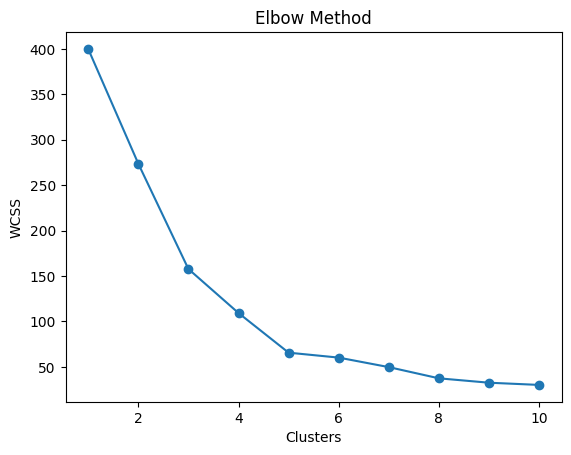

In [20]:
plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [21]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

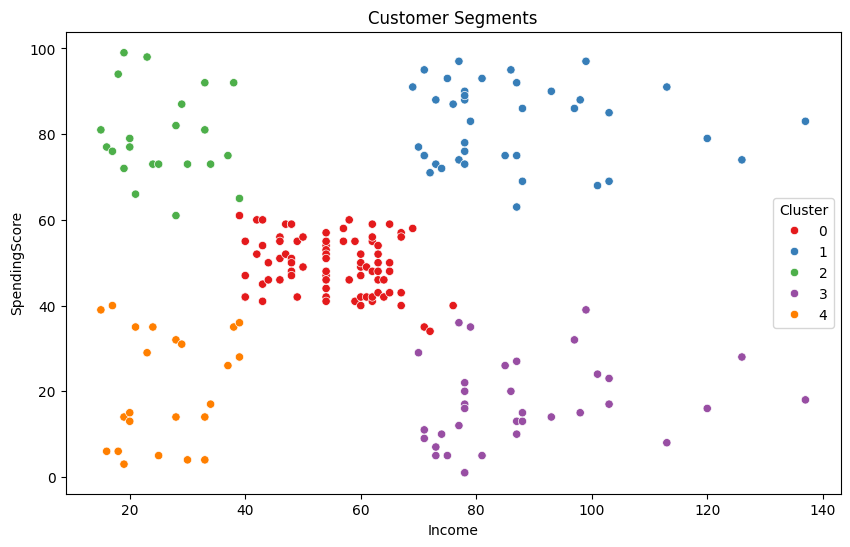

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Income",
    y="SpendingScore",
    hue="Cluster",
    palette="Set1",
    data=df
)

plt.title("Customer Segments")

plt.show()

In [23]:
cluster_summary = df.groupby(
    "Cluster"
).mean(numeric_only=True)

print(cluster_summary)

         CustomerID        Age     Income  SpendingScore
Cluster                                                 
0         86.320988  42.716049  55.296296      49.518519
1        162.000000  32.692308  86.538462      82.128205
2         23.090909  25.272727  25.727273      79.363636
3        164.371429  41.114286  88.200000      17.114286
4         23.000000  45.217391  26.304348      20.913043


In [32]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,25,40,60,100],
    labels=[
        "Young",
        "Adult",
        "Middle Age",
        "Senior"
    ]
)

In [33]:
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [34]:
df.to_csv("Customer_Segmentation_Final.csv", index=False)